In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date

In [4]:
today = date.today()
print("Today's date:", today)
date_today = str(today)
date_today

Today's date: 2023-06-14


'2023-06-14'

In [5]:
tubulin = '[Tubulin] ' r'$(\mu M)$'
tub = 'tub'

DCXconc = '[DCX] ' r'$(n M)$'
DCX = 'DCX'
Type = 'DCX Type'

drug = '[Drug] ' r'$(\mu M)$'#'[SiR] ' r'$(\mu M)$'


Concentration = 'Concentration ' r'$(\mu M)$'
Length = 'Length ' r'$(\mu m)$'
Lifetime = 'Lifetime ' r'$(min)$'
GrowthRate = 'Growth Rate ' r'$(\mu m / min)$'
TimeToNucleate = 'Time to Nucleate ' r'$(min)$'
ShrinkageLength = 'Shrink Length ' r'$(\mu m)$'
ShrinkageLifetime = 'Shrink Lifetime ' r'$(min)$'
ShrinkageRate = 'Shrink Rate ' r'$(\mu m / min)$'

In [6]:
black = '#000000'
grey = '#777777'
blue = '#23459C'
snsblue = '#225b91'
cyan = '#0089CF'
green = '#79BA1A'
purple = '#AB4A9C'
lily = '#CB81EA'
magenta = '#D80B8C'
red = '#e60000'
orange = '#FF7300'
darkorange = '#FF5B00'
lightorange = '#FFAC83'
yellow = '#FFCB05'
lightyellow = '#F9DC2D'
pink = '#FFA4CD'
StartHue1 = Color(purple)
DC1color = list(StartHue1.range_to(Color(pink),3))
StartHue2 = Color(darkorange)
DC2color = list(StartHue2.range_to(Color(lightorange),3))
print(DC1color,DC2color)

palette = [grey,cyan] + list(map(Color.get_hex,DC1color)) + list(map(Color.get_hex,DC2color)) + [green]
parameters = [GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate]

[<Color #ab4a9c>, <Color #e468b8>, <Color #ffa4cd>] [<Color #ff5b00>, <Color #ff8341>, <Color #ffac83>]


## Import Kappa csv ##

In [275]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [276]:
drugtag = 'epod'
drugtype = 'Epothilone D'

folders = [x for x in path.iterdir() if x.is_dir()]
folders = [i for i in folders if str(i.name).rfind(drugtag) != -1]
folders

[WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/2023-05-12_sec-dcx_WT-EpoD/CH1_DCX5nM_typeWT_epod10uM'),
 WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/2023-05-12_sec-dcx_WT-EpoD/CH2_DCX5nM_typeWT_epod10uM'),
 WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/2023-05-12_sec-dcx_WT-EpoD/CH3_DCX5nM_typeWT_epod10uM')]

In [277]:
files = []
for k in folders:
    files0 = [x for x in k.iterdir() if x.is_file()]
    files0 = [i for i in files0 if str(i).rfind('final') != -1 if str(i).rfind('csv') != -1]
    files = files + files0
files

[WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/2023-05-12_sec-dcx_WT-EpoD/CH1_DCX5nM_typeWT_epod10uM/1-Stack_Composite-amplified-final.csv'),
 WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/2023-05-12_sec-dcx_WT-EpoD/CH1_DCX5nM_typeWT_epod10uM/3-Stack_Composite-amplified-final.csv'),
 WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/2023-05-12_sec-dcx_WT-EpoD/CH1_DCX5nM_typeWT_epod10uM/4-Stack_Composite-amplified-final.csv'),
 WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/2023-05-12_sec-dcx_WT-EpoD/CH1_DCX5nM_typeWT_epod10uM/5-Stack_Composite-amplified-final.csv'),
 WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/2023-05-12_sec-dcx_WT-EpoD/CH1_DCX5nM_typeWT_epod10uM/6-Stack_Composite-amplified-final.csv'),
 WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/2023-05-12_sec-dcx_WT-EpoD/CH2_DCX5nM_typeWT_epod10uM/1-Stack_Composite-amplified-final.csv'),
 WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/2023-05-12_sec-dcx_WT-EpoD/CH2_

In [278]:
def findmetadata(tag,end,i):
    n = len(tag)
    locstart = str(i).rfind(tag) 
    locend = str(i).find(end, locstart)
    tag0 = str(i)[locstart+n: locend]
    
    return tag0

In [279]:
dates= []
CH= []
tax= []
dcx = []
dcxtype= []
for i in files:
    dateloc = str(i).rfind("202")   
    dates0 = str(i)[dateloc : dateloc+10]
    dates = dates + [dates0]

    CH0 = findmetadata("CH",'_',i)
    CH = CH + [CH0]  
    
    dcx0 = findmetadata("DCX",'nM',i)
    dcx = dcx + [dcx0] 
    
    type0 = findmetadata("type",'_',i)
    dcxtype = dcxtype + [type0] 
    
    tax0 = findmetadata(drugtag,'uM',i)
    tax = tax + [tax0] 
    

print(dates,CH,dcx, dcxtype,tax,len(dates))

['2023-05-12', '2023-05-12', '2023-05-12', '2023-05-12', '2023-05-12', '2023-05-12', '2023-05-12', '2023-05-12', '2023-05-12', '2023-05-12', '2023-05-12', '2023-05-12', '2023-05-12', '2023-05-12', '2023-05-12', '2023-05-12', '2023-05-12'] ['1', '1', '1', '1', '1', '2', '2', '2', '2', '2', '2', '3', '3', '3', '3', '3', '3'] ['5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5'] ['WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT', 'WT'] ['10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10'] 17


In [280]:
roll = 5
c = 0 
joindata = pd.DataFrame(columns=[] , index=[])
for i in files:
    data0 = pd.read_csv(i, encoding='utf-8')
    
    for j in data0['Curve Name'].unique():
        curvedata = data0[data0['Curve Name'] == j]
        array = curvedata['Green Intensity'].values
        
        curvedata['Date'] = dates[c]
        curvedata['CH'] = CH[c]
        curvedata[DCXconc] = dcx[c]
        curvedata[Type] = dcxtype[c]
        curvedata['Drug Type'] = drugtype
        curvedata[drug] = tax[c]
        curvedata['Filename'] = i.stem
        
        joindata = joindata.append(curvedata, ignore_index=True)
    c += 1
joindata


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # This is added back by InteractiveShellApp.init_path()
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

,Curve Name,Curve Length (um),Average Curvature (um-1),Curvature Std (um-1),X-Coordinate (um),Y-Coordinate (um),Point Curvature (um-1),Point Curvature Sign,Red Intensity,Green Intensity,Blue Intensity,Date,CH,[DCX] $(n M)$,DCX Type,Drug Type,[Drug] $(\mu M)$,Filename
0,CURVE 1,13.960357,0.351648,0.332879,3.671400,31.966500,0.012601,-1,85.0,34.0,34.0,2023-05-12,1,5,WT,Epothilone D,10,1-Stack_Composite-amplified-final
1,CURVE 1,13.960357,0.351648,0.332879,3.736331,31.965051,0.012907,-1,85.0,68.0,68.0,2023-05-12,1,5,WT,Epothilone D,10,1-Stack_Composite-amplified-final
2,CURVE 1,13.960357,0.351648,0.332879,3.800572,31.963671,0.013221,-1,51.0,85.0,85.0,2023-05-12,1,5,WT,Epothilone D,10,1-Stack_Composite-amplified-final
3,CURVE 1,13.960357,0.351648,0.332879,3.864127,31.962360,0.013544,-1,51.0,85.0,85.0,2023-05-12,1,5,WT,Epothilone D,10,1-Stack_Composite-amplified-final
4,CURVE 1,13.960357,0.351648,0.332879,3.927001,31.961116,0.013875,-1,51.0,17.0,17.0,2023-05-12,1,5,WT,Epothilone D,10,1-Stack_Composite-amplified-final
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106235,CURVE 10,15.306086,0.010468,0.007231,60.897370,13.372175,0.001626,1,306.0,17.0,17.0,2023-05-12,3,5,WT,Epothilone D,10,6-Stack_Composite-amplified-final
106236,CURVE 10,15.306086,0.010468,0.007231,60.951499,13.370644,0.001657,1,306.0,17.0,17.0,2023-05-12,3,5,WT,Epothilone D,10,6-Stack_Composite-amplified-final
106237,CURVE 10,15.306086,0.010468,0.007231,61.005992,13.369097,0.001687,1,323.0,34.0,34.0,2023-05-12,3,5,WT,Epothilone D,10,6-Stack_Composite-amplified-final
106238,CURVE 10,15.306086,0.010468,0.007231,61.060853,13.367534,0.001716,1,323.0,34.0,34.0,2023-05-12,3,5,WT,Epothilone D,10,6-Stack_Composite-amplified-final


In [281]:
path.parents[0]

WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves')

In [282]:
newdirectory = str(path.parents[0])+'//Curvature_Data_Sheets'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)

In [283]:
name = dates[0]+ '_'+drugtag+'_jointdata-on_'+date_today +'.csv'
name

'2023-05-12_epod_jointdata-on_2023-06-13.csv'

In [284]:
joindata.to_csv(path/(name), encoding='utf-8', index=False)
joindata.to_csv(newmydir/(name), encoding='utf-8', index=False)

## Join various data sheets ##

In [285]:
#askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = newmydir

In [286]:
files = [x for x in path.iterdir() if x.is_file()]
files = [i for i in files if (str(i)[-9:] != 'Sheet.csv') == True]
files = [i for i in files if str(i).rfind('csv') != -1 if str(i).rfind('jointdata') != -1]

files

[WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/Curvature_Data_Sheets/2023-04-05_tax_jointdata-on_2023-06-13.csv'),
 WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/Curvature_Data_Sheets/2023-04-11_tax_jointdata-on_2023-06-13.csv'),
 WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/Curvature_Data_Sheets/2023-04-25_tax_jointdata-on_2023-06-13.csv'),
 WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/Curvature_Data_Sheets/2023-05-08_tax_jointdata-on_2023-06-13.csv'),
 WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/Curvature_Data_Sheets/2023-05-10_sirtub_jointdata-on_2023-06-13.csv'),
 WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/Curvature_Data_Sheets/2023-05-11_doce_jointdata-on_2023-06-13.csv'),
 WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/Curvature_Data_Sheets/2023-05-12_epod_jointdata-on_2023-06-13.csv'),
 WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/Curvature_Data_Sheets/2023-05-16_sirtub_jointdata-on_2023-06-13

In [287]:
joindata = pd.read_csv(files[0], encoding='utf-8')
for i in range(1,len(files)):
    d = pd.read_csv(files[i], encoding='utf-8')
    joindata = joindata.append(d, ignore_index=True)

mastersheetname = 'jointdata-on_'+date_today+'_MasterSheet.csv'
mastersheetname

'jointdata-on_2023-06-13_MasterSheet.csv'

In [288]:
joindata.to_csv(path/(mastersheetname), encoding='utf-8', index=False)
joindata

,Curve Name,Curve Length (um),Average Curvature (um-1),Curvature Std (um-1),X-Coordinate (um),Y-Coordinate (um),Point Curvature (um-1),Point Curvature Sign,Red Intensity,Green Intensity,Blue Intensity,Date,CH,[DCX] $(n M)$,DCX Type,Drug Type,[Drug] $(\mu M)$,Filename
0,CURVE 1,27.108929,0.333002,0.569584,35.004900,36.460800,0.018782,-1,153.0,68.0,68.0,2023-04-05,5,5,WT,Paclitaxel,10,2-Stack_final_amplified
1,CURVE 1,27.108929,0.333002,0.569584,34.981278,36.466700,0.018370,-1,170.0,17.0,17.0,2023-04-05,5,5,WT,Paclitaxel,10,2-Stack_final_amplified
2,CURVE 1,27.108929,0.333002,0.569584,34.957887,36.472531,0.017925,-1,170.0,17.0,17.0,2023-04-05,5,5,WT,Paclitaxel,10,2-Stack_final_amplified
3,CURVE 1,27.108929,0.333002,0.569584,34.934724,36.478295,0.017448,-1,204.0,0.0,0.0,2023-04-05,5,5,WT,Paclitaxel,10,2-Stack_final_amplified
4,CURVE 1,27.108929,0.333002,0.569584,34.911788,36.483991,0.016935,-1,204.0,0.0,0.0,2023-04-05,5,5,WT,Paclitaxel,10,2-Stack_final_amplified
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537467,CURVE 8,11.242575,0.664717,0.776231,53.554690,14.204073,0.004750,-1,1632.0,170.0,459.0,2023-05-16,1,5,WT,Sir-Tubulin,10,6-Stack_Composite-amplified-final
537468,CURVE 8,11.242575,0.664717,0.776231,53.485662,14.237860,0.004480,-1,4369.0,0.0,357.0,2023-05-16,1,5,WT,Sir-Tubulin,10,6-Stack_Composite-amplified-final
537469,CURVE 8,11.242575,0.664717,0.776231,53.415586,14.272129,0.004224,-1,5389.0,0.0,425.0,2023-05-16,1,5,WT,Sir-Tubulin,10,6-Stack_Composite-amplified-final
537470,CURVE 8,11.242575,0.664717,0.776231,53.344454,14.306886,0.003983,-1,4845.0,0.0,476.0,2023-05-16,1,5,WT,Sir-Tubulin,10,6-Stack_Composite-amplified-final


### If data already joint ###

In [94]:
askfile = filedialog.askopenfilename()
joindata = pd.read_csv(askfile, encoding='utf-8')

In [95]:
path = Path(askfile).parents[0]
path

WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/Curvature_Data_Sheets')

## One Curve ##

In [28]:
keep_columns = ['Date','CH', 'Filename','Curve Name','Point Curvature (um-1)','Red Intensity','Green Intensity','Blue Intensity',DCXconc,Type,taxol]
unique_curve_columns = ['Date','CH', 'Filename','Curve Name']

analze_data = joindata[keep_columns]
data_unique = analze_data[unique_curve_columns].drop_duplicates(subset =unique_curve_columns, keep = 'first')
data_unique


,Date,CH,Filename,Curve Name
0,2023-04-05,5,3-Stack_final_amplified,CURVE 1
768,2023-04-05,5,3-Stack_final_amplified,CURVE 2
1280,2023-04-05,5,3-Stack_final_amplified,CURVE 3
1664,2023-04-05,5,3-Stack_final_amplified,CURVE 4
2432,2023-04-05,5,3-Stack_final_amplified,CURVE 5
2944,2023-04-05,5,3-Stack_final_amplified,CURVE 6
3200,2023-04-05,5,3-Stack_final_amplified,CURVE 7
3584,2023-04-05,5,3-Stack_final_amplified,CURVE 8
3968,2023-04-05,5,3-Stack_final_amplified,CURVE 9
4352,2023-04-05,5,3-Stack_final_amplified,CURVE 10


In [29]:
def single_curve(data,i):
    singlecurve = data.loc[(data['Date'] == data_unique['Date'].values[i]) & 
                 (data['CH'] == data_unique['CH'].values[i]) &
                 (data['Filename'] == data_unique['Filename'].values[i]) &
                 (data['Curve Name'] == data_unique['Curve Name'].values[i])
                ] 
    return singlecurve

In [31]:
singlecurve = single_curve(analze_data,30)
singlecurve

,Date,CH,Filename,Curve Name,Point Curvature (um-1),Red Intensity,Green Intensity,Blue Intensity,[DCX] $(n M)$,DCX Type,[Taxol] $(\mu M)$
13824,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.000645,289.0,51.0,51.0,5,WT,10
13825,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.000679,289.0,51.0,51.0,5,WT,10
13826,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.000714,289.0,170.0,170.0,5,WT,10
13827,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.000751,272.0,357.0,357.0,5,WT,10
13828,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.000789,289.0,323.0,323.0,5,WT,10
...,...,...,...,...,...,...,...,...,...,...,...
14459,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.006428,204.0,68.0,68.0,5,WT,10
14460,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.006359,204.0,68.0,68.0,5,WT,10
14461,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.006290,204.0,85.0,85.0,5,WT,10
14462,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.006221,221.0,102.0,102.0,5,WT,10


In [33]:
def normal_rolling_avg(singlecurve,roll,channels):
    for channel in channels:
        if channel == 'Point Curvature (um-1)':
            singlecurve[channel+' Rolling'] =  singlecurve[channel].rolling(roll, min_periods=1, center=True).mean()
            singlecurve[channel+' Rolling std'] =  singlecurve[channel].rolling(roll, min_periods=1, center=True).std()
        else:   
            max_channel = singlecurve[channel].max()
            min_channel = singlecurve[channel].min()

            singlecurve[channel+' Normalized'] =  (singlecurve[channel] - min_channel) / (max_channel -  min_channel)

            singlecurve[channel+' Rolling'] =  singlecurve[channel+' Normalized'].rolling(roll, min_periods=1, center=True).mean()
            singlecurve[channel+' Rolling std'] =  singlecurve[channel+' Normalized'].rolling(roll, min_periods=1, center=True).std()

    return singlecurve


In [34]:
roll = 50
channels = ['Point Curvature (um-1)','Red Intensity','Green Intensity','Blue Intensity']

data = normal_rolling_avg(singlecurve,roll,channels)
data

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

,Date,CH,Filename,Curve Name,Point Curvature (um-1),Red Intensity,Green Intensity,Blue Intensity,[DCX] $(n M)$,DCX Type,...,Point Curvature (um-1) Rolling std,Red Intensity Normalized,Red Intensity Rolling,Red Intensity Rolling std,Green Intensity Normalized,Green Intensity Rolling,Green Intensity Rolling std,Blue Intensity Normalized,Blue Intensity Rolling,Blue Intensity Rolling std
13824,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.000645,289.0,51.0,51.0,5,WT,...,0.000431,0.500000,0.323333,0.118634,0.047619,0.066667,0.089205,0.047619,0.066667,0.089205
13825,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.000679,289.0,51.0,51.0,5,WT,...,0.000460,0.500000,0.325321,0.116678,0.047619,0.064103,0.088375,0.047619,0.064103,0.088375
13826,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.000714,289.0,170.0,170.0,5,WT,...,0.000490,0.500000,0.327160,0.114811,0.158730,0.061728,0.087533,0.158730,0.061728,0.087533
13827,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.000751,272.0,357.0,357.0,5,WT,...,0.000521,0.458333,0.327381,0.112671,0.333333,0.059524,0.086685,0.333333,0.059524,0.086685
13828,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.000789,289.0,323.0,323.0,5,WT,...,0.000553,0.500000,0.323276,0.112828,0.301587,0.057471,0.085837,0.301587,0.057471,0.085837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14459,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.006428,204.0,68.0,68.0,5,WT,...,0.000496,0.291667,0.301389,0.058603,0.063492,0.028042,0.029676,0.063492,0.028042,0.029676
14460,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.006359,204.0,68.0,68.0,5,WT,...,0.000488,0.291667,0.306034,0.053725,0.063492,0.029009,0.029717,0.063492,0.029009,0.029717
14461,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.006290,204.0,85.0,85.0,5,WT,...,0.000480,0.291667,0.311012,0.047415,0.079365,0.030045,0.029724,0.079365,0.030045,0.029724
14462,2023-04-05,5,7-Stack_final_amplified,CURVE 3,0.006221,221.0,102.0,102.0,5,WT,...,0.000470,0.333333,0.311728,0.048164,0.095238,0.031158,0.029690,0.095238,0.031158,0.029690


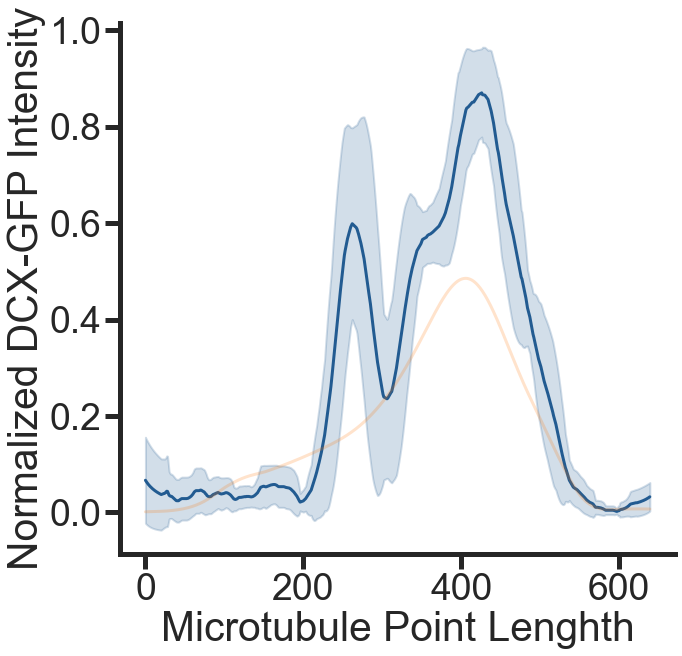

In [36]:
#data = data.sort_values(by=['Point Curvature (um-1)'])

fig, ax = plt.subplots(1,1,figsize=(10.5,10))

#x = data['Point Curvature (um-1)'].values
x = range(0,len(data['Green Intensity'].values))
y = data['Point Curvature (um-1) Rolling'].values
mean = data['Green Intensity Rolling'].values
std = data['Green Intensity Rolling std'].values

plt.plot(x, mean, color=snsblue)
plt.plot(x, y, color=orange, alpha=0.2)
plt.fill_between(x, mean - std, mean + std, color=snsblue, alpha=0.2)

ax.set_ylabel('Normalized DCX-GFP Intensity')
ax.set_xlabel('Microtubule Point Lenghth')
#ax.set_xlim(0,1.5)
#ax.set_ylim(0,0.8)

sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()

#plt.savefig(path/('curvature_dcx_'+date_today+'.svg'))

## Normalize by FOV ##

In [289]:
keep_columns = ['Date','CH', 'Filename','Curve Name','Point Curvature (um-1)','Red Intensity','Green Intensity','Blue Intensity',DCXconc,Type,drug,'Drug Type']
unique_curve_columns = ['Date','CH', 'Filename']

analze_data = joindata[keep_columns]
data_unique = analze_data[unique_curve_columns].drop_duplicates(subset =unique_curve_columns, keep = 'first')
data_unique

,Date,CH,Filename
0,2023-04-05,5,2-Stack_final_amplified
4736,2023-04-05,5,3-Stack_final_amplified
9344,2023-04-05,5,4-Stack_final_amplified
12672,2023-04-05,5,6-Stack_final_amplified
17280,2023-04-05,5,7-Stack_final_amplified
...,...,...,...
514944,2023-05-16,1,2-Stack_Composite-amplified-final
517888,2023-05-16,1,3-Stack_Composite-amplified-final
522880,2023-05-16,1,4-Stack_Composite-amplified-final
525440,2023-05-16,1,5-Stack_Composite-amplified-final


In [290]:
def single_FOV(data,i):
    singleFOV = data.loc[(data['Date'] == data_unique['Date'].values[i]) & 
                 (data['CH'] == data_unique['CH'].values[i]) &
                 (data['Filename'] == data_unique['Filename'].values[i]) 
                        ] 
    return singleFOV

In [291]:
def normalizeFOV(singleFOV,channels):
    for channel in channels:
            max_channel = singleFOV[channel].max()
            min_channel = singleFOV[channel].min()

            singleFOV[channel+' Normalized'] =  (singleFOV[channel] - min_channel) / (max_channel -  min_channel)

    return singleFOV


In [292]:
channels = ['Red Intensity','Green Intensity','Blue Intensity']

results = pd.DataFrame(columns=[] , index=[])
for i in range(0,len(data_unique)):
    
    singleFOV = single_FOV(analze_data,i)
    results0 = normalizeFOV(singleFOV,channels)
    results = pd.concat([results, results0], sort=False)
    
results

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,Date,CH,Filename,Curve Name,Point Curvature (um-1),Red Intensity,Green Intensity,Blue Intensity,[DCX] $(n M)$,DCX Type,[Drug] $(\mu M)$,Drug Type,Red Intensity Normalized,Green Intensity Normalized,Blue Intensity Normalized
0,2023-04-05,5,2-Stack_final_amplified,CURVE 1,0.018782,153.0,68.0,68.0,5,WT,10,Paclitaxel,0.290323,0.045977,0.045977
1,2023-04-05,5,2-Stack_final_amplified,CURVE 1,0.018370,170.0,17.0,17.0,5,WT,10,Paclitaxel,0.322581,0.011494,0.011494
2,2023-04-05,5,2-Stack_final_amplified,CURVE 1,0.017925,170.0,17.0,17.0,5,WT,10,Paclitaxel,0.322581,0.011494,0.011494
3,2023-04-05,5,2-Stack_final_amplified,CURVE 1,0.017448,204.0,0.0,0.0,5,WT,10,Paclitaxel,0.387097,0.000000,0.000000
4,2023-04-05,5,2-Stack_final_amplified,CURVE 1,0.016935,204.0,0.0,0.0,5,WT,10,Paclitaxel,0.387097,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537467,2023-05-16,1,6-Stack_Composite-amplified-final,CURVE 8,0.004750,1632.0,170.0,459.0,5,WT,10,Sir-Tubulin,0.248062,0.043860,0.341772
537468,2023-05-16,1,6-Stack_Composite-amplified-final,CURVE 8,0.004480,4369.0,0.0,357.0,5,WT,10,Sir-Tubulin,0.664083,0.000000,0.265823
537469,2023-05-16,1,6-Stack_Composite-amplified-final,CURVE 8,0.004224,5389.0,0.0,425.0,5,WT,10,Sir-Tubulin,0.819121,0.000000,0.316456
537470,2023-05-16,1,6-Stack_Composite-amplified-final,CURVE 8,0.003983,4845.0,0.0,476.0,5,WT,10,Sir-Tubulin,0.736434,0.000000,0.354430


In [293]:
mastersheetname = 'jointdata-on_'+date_today+'_NormalizedMasterSheet.csv'
mastersheetname

'jointdata-on_2023-06-13_NormalizedMasterSheet.csv'

In [294]:
results.to_csv(path/(mastersheetname), encoding='utf-8', index=False)


# From NORMALIZED Mastersheet  #

In [7]:
askfile = filedialog.askopenfilename()
joindata = pd.read_csv(askfile, encoding='utf-8')

In [11]:
results = joindata

In [8]:
path = Path(askfile).parents[0]
path

WindowsPath('D:/Sofia/2023_1winter-SEC-expansion-curves/Curvature_Data_Sheets')

In [70]:
dcxT = 'WT'
drugT = 'Sir-Tubulin'

resultsN = results[(results['Drug Type'] == drugT) & (results['DCX Type'] == dcxT)]
countingn = resultsN.groupby(['DCX Type','Drug Type','CH','Date','Filename','Curve Name']).size()
datanumber = resultsN.groupby(['DCX Type','Drug Type']).size()

In [71]:
datanumber

DCX Type  Drug Type  
WT        Sir-Tubulin    54912
dtype: int64

In [72]:
countingn

DCX Type  Drug Type    CH  Date        Filename                           Curve Name
WT        Sir-Tubulin  1   2023-05-10  2-Stack_Composite-amplified-final  CURVE 1        384
                                                                          CURVE 2       1280
                                       3-Stack_Composite-amplified-final  CURVE 1        384
                                                                          CURVE 2       1152
                                       4-Stack_Composite-amplified-final  CURVE 1        896
                                                                                        ... 
                       2   2023-05-10  6-Stack_Composite-amplified-final  CURVE 1        896
                                                                          CURVE 2       1024
                                                                          CURVE 3        384
                                                                          CURV

## Bin data and Plot ##

In [12]:
DataLabel = [['Tubulin'],['DCX-GFP'],['SiR-Tubulin']]
channels=['Red','Green','Blue']
colors=[magenta,green,blue]

In [13]:
data = results.sort_values(by=['Point Curvature (um-1)'])
data = data[data['Drug Type'] == 'Paclitaxel']

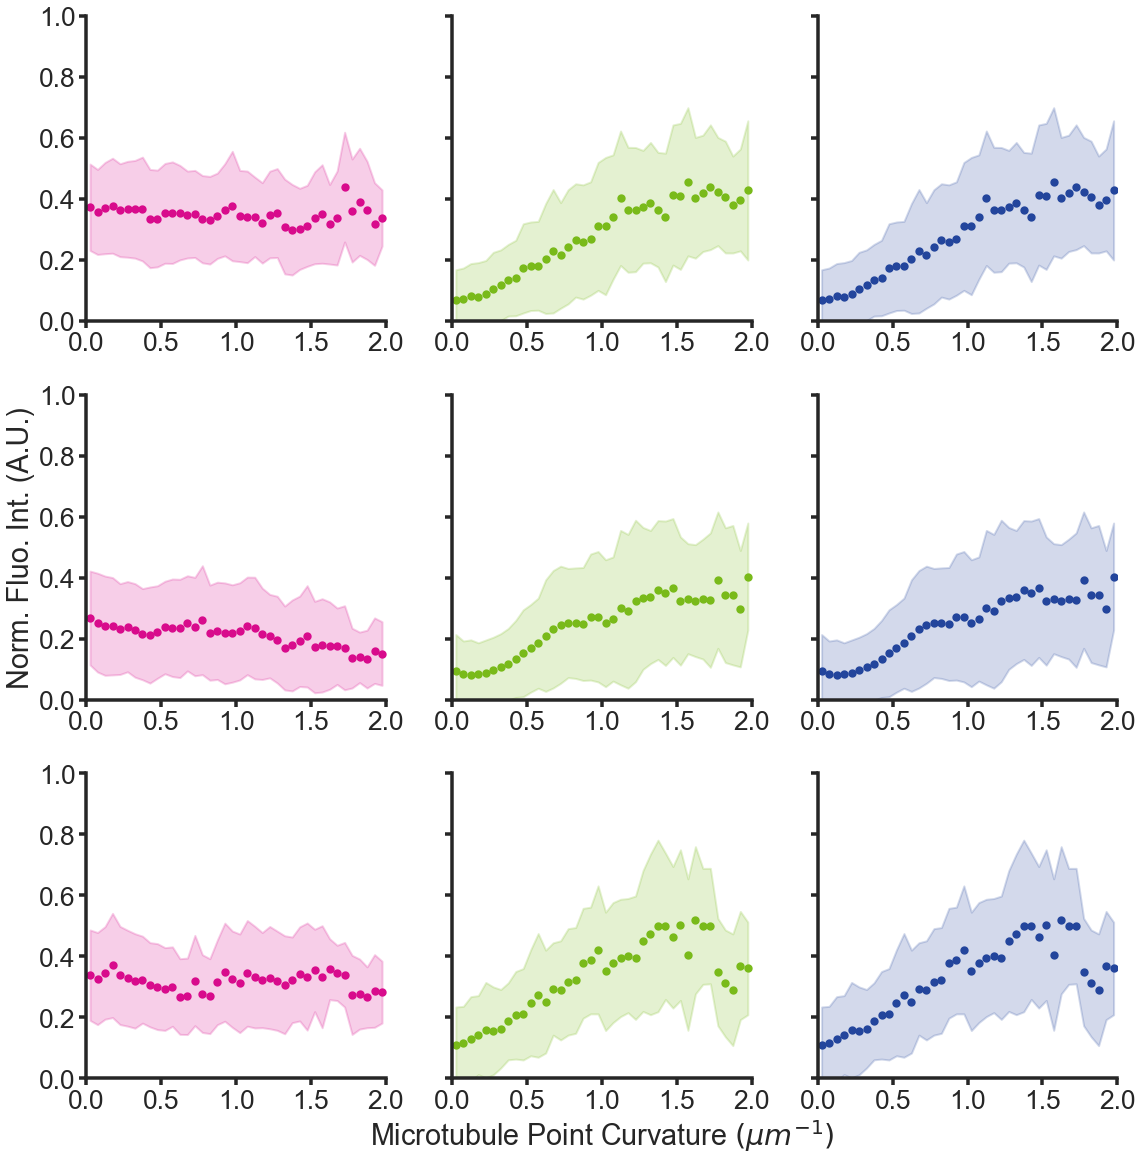

In [23]:
scattersize = 40

fig, ax = plt.subplots(3,3,figsize=(16.5,16.75), sharey=True)
#gs = fig.add_gridspec(1, 3, hspace=0, wspace=0)
count = 0
#fig.subplots_adjust(hspace=0)
for i in np.arange(len(ax)):
    
    dcxtype  = data['DCX Type'].unique()
    
    datadcxtype = data[data['DCX Type']== dcxtype[i]]
    
    binsize = 0.05
    limX= 2
    data_interval_mean = datadcxtype.groupby(pd.cut(datadcxtype['Point Curvature (um-1)'], np.arange(0, limX+binsize, binsize))).mean()
    data_interval_std = datadcxtype.groupby(pd.cut(datadcxtype['Point Curvature (um-1)'], np.arange(0, limX+binsize, binsize))).std()
    data_interval_mean['Bin Center'] =np.arange(binsize, limX+binsize, binsize)-binsize/2
    data_interval_std['Bin Center'] =np.arange(binsize, limX+binsize, binsize)-binsize/2
    
    
    
    for j in np.arange(len(ax)):
    
            
        x = data_interval_mean['Bin Center'].values
        channel = channels[j]
        mean = data_interval_mean[channel+' Intensity Normalized'].values
        std = data_interval_std[channel+' Intensity Normalized'].values
        color = colors[j]
        ax[i][j].scatter(x, mean, color=color,s=scattersize)
        ax[i][j].fill_between(x, mean - std, mean + std, color=color, alpha=0.2)
        ax[i][j].set_ylim(0,1)
        ax[i][j].set_xticks(np.arange(0, 2.1, 0.5))
        ax[i][j].set_xlim(0,2)
        
        ax[i][j].spines['left'].set_lw(3.5)
        ax[i][j].spines['bottom'].set_lw(3.5)
        ax[i][j].tick_params(axis='both', width = 3.5, length = 7)

        #ax[i][j].legend(DataLabel[j],loc='upper right')
        #ax[i][1].legend(DataLabel[j-1],loc='upper right',title='DCX: '+dcxtype[i])

        


ax[1][0].set_ylabel('Norm. Fluo. Int. (A.U.)')
ax[2][1].set_xlabel('Microtubule Point Curvature '  r'$(\mu m ^{-1})$')

#fig.supxlabel('Microtubule Point Curvature ' r'$(\mu m ^{-1})$')

sns.set_style("ticks")
sns.despine()

sns.set_context("poster", font_scale=1.15, rc={"lines.linewidth":3.0})

plt.tight_layout()

plt.savefig(path/('curvature_dcx_tax'+date_today+'.svg'))

In [24]:
data = results.sort_values(by=['Point Curvature (um-1)'])
data = data[data['Drug Type'] != 'Paclitaxel']

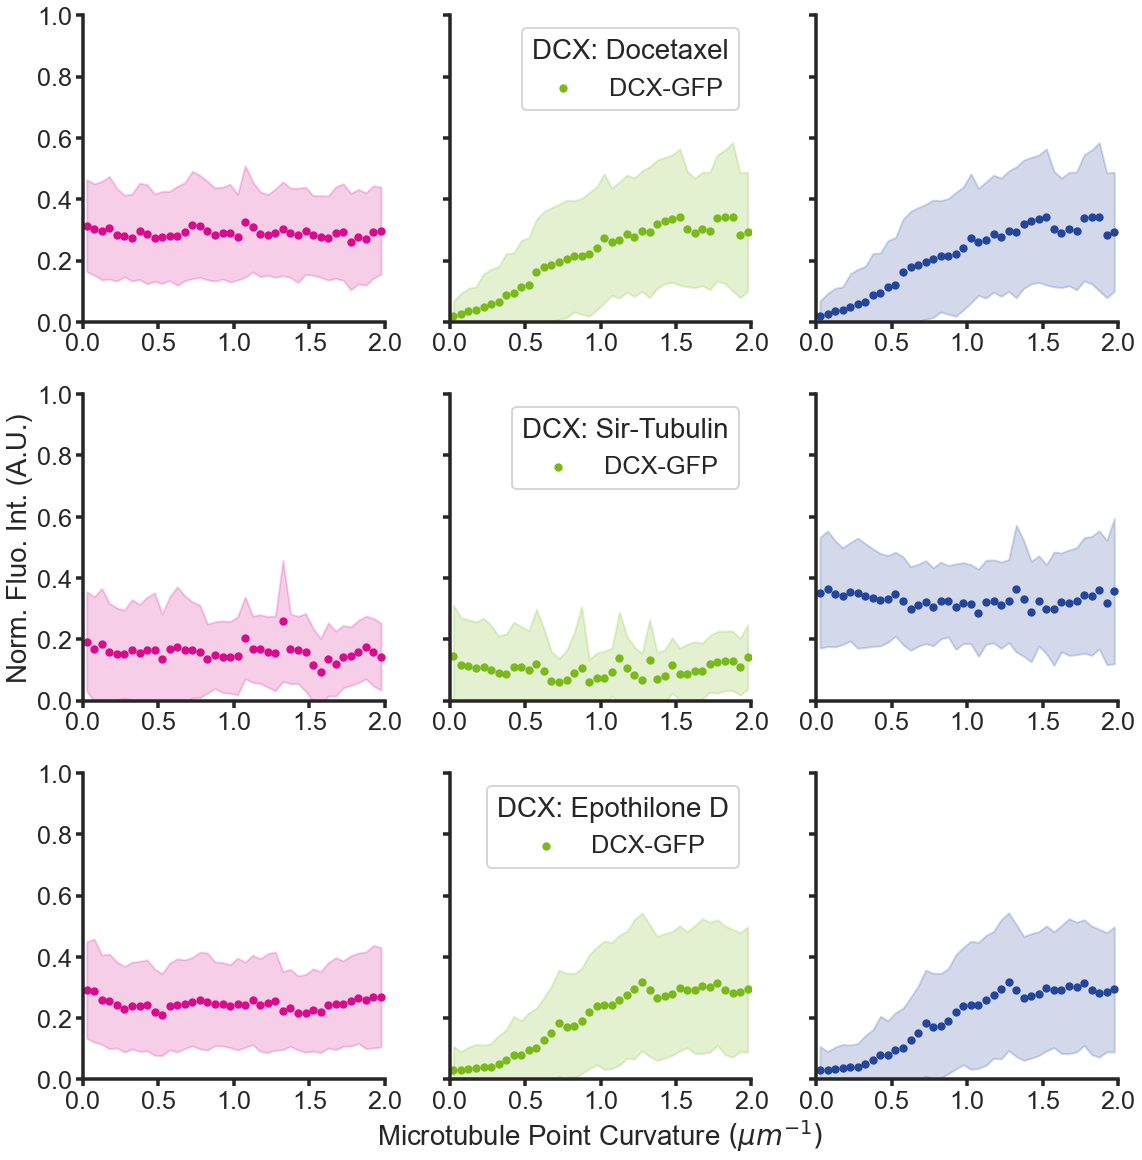

In [26]:

fig, ax = plt.subplots(3,3,figsize=(16.5,16.75), sharey=True)
gs = fig.add_gridspec(1, 3, hspace=0, wspace=0)
count = 0

for i in np.arange(len(ax)):
    
    dcxtype  = data['Drug Type'].unique()
    
    datadcxtype = data[data['Drug Type']== dcxtype[i]]
    binsize = 0.05
    limX= 2
    data_interval_mean = datadcxtype.groupby(pd.cut(datadcxtype['Point Curvature (um-1)'], np.arange(0, limX+binsize, binsize))).mean()
    data_interval_std = datadcxtype.groupby(pd.cut(datadcxtype['Point Curvature (um-1)'], np.arange(0, limX+binsize, binsize))).std()
    data_interval_mean['Bin Center'] =np.arange(binsize, limX+binsize, binsize)-binsize/2
    data_interval_std['Bin Center'] =np.arange(binsize, limX+binsize, binsize)-binsize/2
    
    
    
    for j in np.arange(len(ax)):
    
            
        x = data_interval_mean['Bin Center'].values
        channel = channels[j]
        mean = data_interval_mean[channel+' Intensity Normalized'].values
        std = data_interval_std[channel+' Intensity Normalized'].values
        color = colors[j]
        ax[i][j].scatter(x, mean, color=color,s=scattersize)
        ax[i][j].fill_between(x, mean - std, mean + std, color=color, alpha=0.2)
        ax[i][j].set_ylim(0,1)
        ax[i][j].set_xticks(np.arange(0, 2.1, 0.5))
        ax[i][j].set_xlim(0,2)
        
        ax[i][j].spines['left'].set_lw(3.5)
        ax[i][j].spines['bottom'].set_lw(3.5)
        ax[i][j].tick_params(axis='both', width = 3.5, length = 7)

        #ax[i][j].legend(DataLabel[j],loc='upper right')
        ax[i][1].legend(DataLabel[j-1],loc='upper right',title='DCX: '+dcxtype[i])

        


ax[1][0].set_ylabel('Norm. Fluo. Int. (A.U.)')
ax[2][1].set_xlabel('Microtubule Point Curvature '  r'$(\mu m ^{-1})$')

#fig.supxlabel('Microtubule Point Curvature ' r'$(\mu m ^{-1})$')

sns.set_style("ticks")
sns.despine()

sns.set_context("poster", font_scale=1.15, rc={"lines.linewidth":3.0})

plt.tight_layout()

#plt.savefig(path/('curvature_dcx_drugs'+date_today+'.svg'))

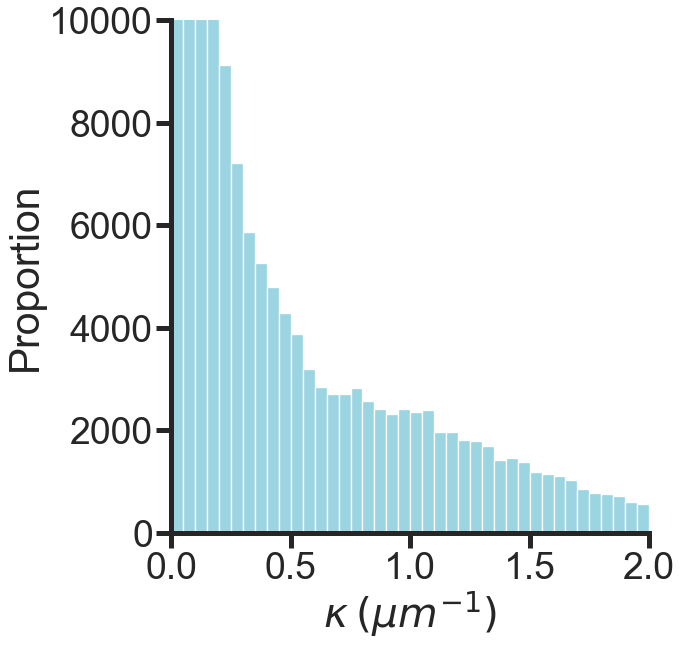

In [321]:
fig, ax = plt.subplots(1,1,figsize=(10.5,10))
sns.histplot(data, x='Point Curvature (um-1)',bins=np.arange(0, limX+binsize, binsize), color='#7BC8D9')#, stat='probability')
#n, bins, patches = plt.hist(x, 50, density = True, facecolor='#7BC8D9')

ax.set_ylabel('Proportion')
ax.set_xlabel( r'$\kappa \: (\mu m ^{-1})$')
ax.set_xlim(0,2)
ax.set_ylim(0,10000)
#plt.yticks([0,0.15,0.3])

sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()

plt.savefig(path/('histogram_curves'+date_today+'.svg'))